# 📘 Agentic 架构 2：Tool Use（工具使用）

本 notebook 介绍第二种、也是最具变革性的 agentic 架构之一：**Tool Use**。该模式将大语言模型的推理能力与真实、动态世界连接起来。

没有工具时，LLM 是一个封闭系统，知识被冻结在训练数据中。它无法知道今日天气、股价或公司数据库里的订单状态。赋予 agent 使用工具的能力，可克服这一根本局限，使其能查询 API、搜索数据库并获取实时信息，从而给出不仅经过推理、而且事实准确、及时且相关的答案。

### 定义
**Tool Use** 架构使基于 LLM 的 agent 能够调用外部函数或 API（即「工具」）。当仅靠内部知识无法回答用户问题时，agent 自主判断是否需要工具，并选择应调用哪一个以获取所需信息。

### 高层工作流

1. **接收查询：** agent 收到用户请求。
2. **决策：** agent 分析查询与可用工具，判断是否需要工具才能准确作答。
3. **行动：** 若需要工具，agent 构造对该工具的调用（例如以正确参数调用特定函数）。
4. **观察：** 系统执行工具调用，将结果（「观察」）返回给 agent。
5. **综合：** agent 将工具输出纳入推理过程，生成面向用户的、有依据的最终答案。

### 适用场景 / 应用
* **研究助手：** 通过网页搜索 API 回答需要最新信息的问题。
* **企业助手：** 查询内部数据库，例如「上周有多少新用户注册？」
* **科学与数学任务：** 使用计算器或 WolframAlpha 等计算引擎完成 LLM 常难以精确完成的计算。

### 优势与局限
* **优势：**
    * **事实锚定：** 通过拉取真实、实时数据，显著减少幻觉。
    * **可扩展性：** 只需增加新工具即可持续扩展 agent 能力。
* **局限：**
    * **集成成本：** 需要仔细「接线」——定义工具、管理 API 密钥、处理工具失败等。
    * **工具可信度：** 回答质量依赖所使用工具的可靠性与准确性；agent 必须信任工具提供的信息正确。

## 阶段 0：基础与环境

与之前一样，先配置环境：安装所需库，并为 DeepSeek、LangSmith 以及本 notebook 将使用的具体工具配置 API 密钥。

### 步骤 0.1：安装核心库

**本节将做什么：**
安装编排用库（`langchain-openai`、`langgraph`）、环境管理（`python-dotenv`）与打印（`rich`）。此外会安装 `tavily-python`，它为我们将提供给 agent 的强大网页搜索工具提供易用的 API。

In [1]:
# !pip install -q -U langchain-openai langchain langgraph rich python-dotenv tavily-python

### 步骤 0.2：导入库并配置密钥

**本节将做什么：**
导入所需模块，使用 `python-dotenv` 加载 API 密钥。本 notebook 需要 DeepSeek（LLM）、LangSmith（追踪）和 Tavily（网页搜索）的密钥。

**需要操作：** 在本目录创建 `.env` 并填入密钥：
```
DEEPSEEK_API_KEY="your_deepseek_api_key_here"
LANGCHAIN_API_KEY="your_langsmith_api_key_here"
TAVILY_API_KEY="your_tavily_api_key_here"
```

In [4]:
import os
import json
from typing import List, Annotated, TypedDict, Optional
from dotenv import load_dotenv

# DeepSeek and LangChain components
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import BaseMessage, ToolMessage
from pydantic import BaseModel, Field

# LangGraph components
from langgraph.graph import StateGraph, END
from langgraph.graph.message import AnyMessage, add_messages
from langgraph.prebuilt import ToolNode

# For pretty printing
from rich.console import Console
from rich.markdown import Markdown

# --- API Key and Tracing Setup ---
load_dotenv(override=True)
api_key = os.getenv("DEEPSEEK_API_KEY")

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "Agentic Architecture - Tool Use (DeepSeek)"

# Check that the keys are set
for key in ["DEEPSEEK_API_KEY", "LANGCHAIN_API_KEY", "TAVILY_API_KEY"]:
    if not os.environ.get(key):
        print(f"{key} not found. Please create a .env file and set it.")

print("Environment variables loaded and tracing is set up.")

Environment variables loaded and tracing is set up.


## 阶段 1：定义 agent 的工具箱

agent 的能力取决于可用工具。本阶段将定义并测试要赋予 agent 的工具：实时网页搜索。

### 步骤 1.1：创建并测试网页搜索工具

**本节将做什么：**
实例化 `TavilySearchResults` 工具。定义工具时最关键的是其**描述（description）**：LLM 依靠该自然语言描述理解工具用途与调用时机。清晰、准确的描述对 agent 做出正确决策至关重要。随后直接测试工具，查看原始输出格式。
前往 Tavily 官网 (tavily.com),即可获得免费1000次的api调用机会。

In [5]:
# Initialize the tool. We can set the max number of results to keep the context concise.
search_tool = TavilySearchResults(max_results=2)

# It's crucial to give the tool a clear name and description for the agent
search_tool.name = "web_search"
search_tool.description = "A tool that can be used to search the internet for up-to-date information on any topic, including news, events, and current affairs."

tools = [search_tool]
print(f"Tool '{search_tool.name}' created with description: '{search_tool.description}'")

console = Console()

# Let's test the tool directly to see its output format
print("\n--- Testing the tool directly ---")
test_query = "What was the score of the last Super Bowl?"
test_result = search_tool.invoke({"query": test_query})
console.print(f"[bold green]Query:[/bold green] {test_query}")
console.print("\n[bold green]Result:[/bold green]")
console.print(test_result)

Tool 'web_search' created with description: 'A tool that can be used to search the internet for up-to-date information on any topic, including news, events, and current affairs.'

--- Testing the tool directly ---


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


Query: What was the score of the last Super Bowl?

Result:

[
    {
        'title': 'Super Bowl LX - Wikipedia',
        'url': 'https://en.wikipedia.org/wiki/Super_Bowl_LX',
        'content': '### Pre-game notes\n\n[edit]\n\nThe two franchises previously met in 2014\'s Super Bowl XLIX, 
in which the Patriots defeated the Seahawks 28–24. No players remained on either team since that Super Bowl, with 
McDaniels being the only coach to appear in both games.( Seahawks general manager John Schneider "John Schneider 
(American football executive)") became the first NFL general manager to reach multiple Super Bowls with a different
roster and head coach.(\n\nThis was the first Super Bowl since Super Bowl XXXVIII to feature two teams that missed 
the playoffs the previous season. It was also the most unlikely Super Bowl matchup in at least 50 years based on 
preseason odds, with Seattle 60–1 to win the Super Bowl and New England 80–1.( [...] | Super Bowl (1970–present) | 
1970(V)  1971(VI)  1972(VII)  1973(VIII)  1974(IX)  1975(X)  1976(XI)  1977(XII)  1978(XIII)  1979(XIV)  1980(XV)  
1981(XVI)  1982(XVII)  1983(XVIII)  1984(XIX)  1985(XX)  1986(XXI)  1987(XXII)  1988(XXIII)  1989(XXIV)  1990(XXV) 
1991(XXVI)  1992(XXVII)  1993(XXVIII)  1994(XXIX)  1995(XXX)  1996(XXXI)  1997(XXXII)  1998(XXXIII)  1999(XXXIV)  
2000(XXXV)  2001(XXXVI)  2002(XXXVII)  2003(XXXVIII)  2004(XXXIX)  2005(XL)  2006(XLI)  2007(XLII)  2008(XLIII)  
2009(XLIV)  2010(XLV)  2011(XLVI)  2012(XLVII)  2013(XLVIII)  2014(XLIX)  2015(50)  2016(LI)  2017(LII)  2018(LIII)
2019(LIV)  2020(LV)  2021(LVI)  2022(LVII)  2023(LVIII)  2024(LIX)  2025(LX)  _2026(LXI)_  _2027(LXII)_ | [...] The
Seahawks\' victory was their second, previously having won 2013\'s Super Bowl XLVIII during their Legion of Boom 
era. Led by their Dark Side "The Dark Side (Seattle Seahawks)") defense, they were making their fourth appearance 
with a 14–3 record and the NFC\'s top seed. The Patriots, who finished with a 14–3 record and the AFC\'s second 
seed, extended their record of appearances to 12. They were seeking a record seventh title and their first since 
the Brady–Belichick era after last winning 2018\'s Super Bowl LIII. The two franchises previously met in Super Bowl
XLIX, which was won by the Patriots.',
        'score': 0.7892337
    },
    {
        'title': 'Super Bowl Scores Last 10 Years | StatMuse',
        'url': 'https://www.statmuse.com/nfl/ask/super-bowl-scores-last-10-years',
        'content': 'Sign in\n\n NBA\n NHL\n FC\n MLB\n NFL\n CFB\n WNBA\n PGA\n Money\n\n Trending Sports\n 
Trending Money\n Trending Live\n\n Data & Glossary\n\nSign in\n\nSign in\n\n Home\n\n NBA\n NHL\n FC\n MLB\n NFL\n 
CFB\n WNBA\n PGA\n Money\n\n Scores\n\n Trending\n\n Trending Sports\n Trending Money\n Trending Live\n\n 
Examples\n\n Data & Glossary\n\n Gallery\n\n About\n\n Blog\n\n Shop\n\nsuper bowl scores last 10 years\n\n# The 
New England Patriots were defeated by the Seattle Seahawks, 29 to 13, in Super Bowl LX on February 8.\n\nSun, Feb 
8, 2026\n\nSeahawks\n\nPatriots\n\nSun, Feb 9, 2025\n\nChiefs\n\nEagles\n\nFinal\n\nSun, Feb 11, 2024\n\n49ers 
\n\n22\n\nChiefs \n\nChiefs\n\nFinal\n\nSun, Feb 12, 2023\n\nChiefs \n\nChiefs\n\n38\n\nEagles 
\n\nEagles\n\n35\n\nFinal\n\nSun, Feb 13, 2022\n\nRams \n\nRams\n\n23\n\nBengals \n\nBengals\n\n20\n\nFinal\n\nSun,
Feb 7, 2021\n\nChiefs \n\nChiefs\n\n9\n\nBuccaneers \n\nBuccaneers [...] | 49ers 49ers - w | 12 | 5 | 0 | .706 |\n|
Cardinals Cardinals - e | 3 | 14 | 0 | .176 |',
        'score': 0.70740473
    }
]

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


**输出说明：**
测试展示了 `web_search` 工具的原始输出：返回字典列表，每个字典包含搜索结果的 URL 与内容片段。agent 决定使用工具后，收到的「观察」正是这种结构化信息。工具有效后，即可构建学会使用它的 agent。

## 阶段 2：用 LangGraph 构建使用工具的 agent

接下来构建 agentic 工作流：让 LLM「知道」有哪些工具，并构建图结构，使其能循环执行「思考—行动—观察」——这正是 Tool Use 的核心。

### 步骤 2.1：定义图状态

**本节将做什么：**
使用工具的 agent 的状态通常是表示对话历史的消息列表，其中包含用户问题、agent 的思考与工具调用、以及工具返回结果。我们使用可存放任意 LangChain 消息类型的 `TypedDict`。

In [6]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

print("AgentState TypedDict defined to manage conversation history.")

AgentState TypedDict defined to manage conversation history.


### 步骤 2.2：将工具绑定到 LLM

**本节将做什么：**
关键一步是让 LLM「感知」工具。使用 `.bind_tools()`，将工具名称与描述传入 LLM 的系统提示，使模型能根据描述决定何时调用工具。

In [7]:
llm = ChatOpenAI(
    model="deepseek-chat",
    api_key=api_key,
    base_url="https://api.deepseek.com/v1",
    temperature=0,
)

# Bind the tools to the LLM, making it tool-aware
llm_with_tools = llm.bind_tools(tools)

print("LLM has been bound with the provided tools.")

LLM has been bound with the provided tools.


### 步骤 2.3：定义 agent 节点

**本节将做什么：**
图中有两个主要节点：
1. **`agent_node`：** 「大脑」。用当前对话历史调用 LLM；回复要么是最终答案，要么是工具调用请求。
2. **`tool_node`：** 「双手」。接收来自 `agent_node` 的工具调用请求，执行对应工具并返回输出。我们使用 LangGraph 预置的 `ToolNode`。

In [8]:
def agent_node(state: AgentState):
    """The primary node that calls the LLM to decide the next action."""
    console.print("--- AGENT: Thinking... ---")
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

# The ToolNode is a pre-built node from LangGraph that executes tools
tool_node = ToolNode(tools)

print("Agent node and Tool node have been defined.")

Agent node and Tool node have been defined.


### 步骤 2.4：定义条件路由

**本节将做什么：**
`agent_node` 运行后需决定下一步。路由函数检查 agent 的最后一条消息：若包含 `tool_calls` 属性，说明需要调用工具，则路由到 `tool_node`；否则表示已有最终答案，可结束工作流。

In [9]:
def router_function(state: AgentState) -> str:
    """Inspects the agent's last message to decide the next step."""
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        # The agent has requested a tool call
        console.print("--- ROUTER: Decision is to call a tool. ---")
        return "call_tool"
    else:
        # The agent has provided a final answer
        console.print("--- ROUTER: Decision is to finish. ---")
        return "__end__"

print("Router function defined.")

Router function defined.


## 阶段 3：组装并运行工作流

将所有组件连接成可执行的完整图，并运行一条迫使 agent 使用新网页搜索能力的查询。

### 步骤 3.1：构建并可视化图

**本节将做什么：**
创建 `StateGraph` 并添加节点与边。关键是使用 `router_function` 的条件边，形成 agent 的主推理回路：`agent -> router -> tool -> agent`。

Tool-using agent graph compiled successfully!


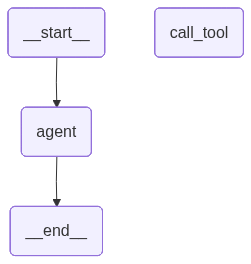

In [11]:
graph_builder = StateGraph(AgentState)

# Add the nodes
graph_builder.add_node("agent", agent_node)
graph_builder.add_node("call_tool", tool_node)

# Set the entry point
graph_builder.set_entry_point("agent")

# Add the conditional router
graph_builder.add_conditional_edges(
    "agent",
    router_function,
)

# Add the edge from the tool node back to the agent to complete the loop
graph_builder.add_edge("call_tool", "agent")

# Compile the graph
tool_agent_app = graph_builder.compile()

print("Tool-using agent graph compiled successfully!")

# Visualize the graph (using Mermaid, no pygraphviz needed)
from IPython.display import Image, display
try:
    display(Image(tool_agent_app.get_graph().draw_mermaid_png()))
except Exception:
    # Fallback: render as Mermaid text
    print(tool_agent_app.get_graph().draw_mermaid())

**输出说明：**
图已编译完成。可视化清晰展示 agent 的推理回路：从 `agent` 节点开始，条件边（菱形）进行分流。若需要工具则进入 `call_tool`，输出再喂回 `agent` 进行综合；若不需要工具则进入 `__end__`。该结构完整实现了 Tool Use 模式。

### 步骤 3.2：端到端执行

**本节将做什么：**
使用训练数据中不可能直接包含的问题运行 agent，迫使其使用网页搜索。流式输出中间步骤，观察推理过程展开。

In [12]:
user_query = "What were the main announcements from Apple's latest WWDC event?"
initial_input = {"messages": [("user", user_query)]}

console.print(f"[bold cyan]🚀 Kicking off Tool Use workflow for request:[/bold cyan] '{user_query}'\n")

for chunk in tool_agent_app.stream(initial_input, stream_mode="values"):
    chunk["messages"][-1].pretty_print()
    console.print("\n---\n")

console.print("\n[bold green]✅ Tool Use workflow complete![/bold green]")

🚀 Kicking off Tool Use workflow for request: 'What were the main announcements from Apple's latest WWDC event?'

================================ Human Message =================================

What were the main announcements from Apple's latest WWDC event?


---

--- AGENT: Thinking... ---

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


...

--- ROUTER: Decision is to finish. ---

================================== Ai Message ==================================

Based on my search results, here are the main announcements from Apple's latest WWDC 2024 event:

## **Major Announcements:**

### **1. Apple Intelligence - The Big AI Push**
- Apple's new personal intelligence system that combines generative AI with personal context
- Deeply integrated into iOS 18, iPadOS 18, and macOS Sequoia
- Available on iPhone 15 Pro/Pro Max and devices with M1 chip or later
- Features include Writing Tools for text summarization and email drafting
- Built with privacy as a core principle

### **2. Siri Gets Major AI Upgrade**
- Siri can now tap into OpenAI's ChatGPT when needed
- Users will be asked for permission before sharing queries with ChatGPT
- ChatGPT integration will be free without requiring an account
- Siri can now act on your behalf in apps using voice commands
- Will support other third-party AI models in the future

### **3. iOS 18 - Biggest Customization Update Ever

---

✅ Tool Use workflow complete!

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


## 阶段 4：评估

agent 运行完毕后，可评估其表现。对使用工具的 agent，我们关心两点：工具是否用对，以及基于工具输出综合出的最终答案质量如何。

### 步骤 4.1：分析执行轨迹

**本节将做什么：**
根据上一步的流式输出，可追踪 agent 的完整思考过程。输出中可见流经图状态的不同消息类型（带 `tool_calls` 的 `AIMessage`、含结果的 `ToolMessage` 等）。

**输出说明：**
执行轨迹清晰展示了 Tool Use 模式：
1. 第一条来自 `agent` 节点，是包含 `tool_calls` 的 `AIMessage`，表明 LLM 正确决定使用 `web_search`。
2. 下一条是 `ToolMessage`，即 `tool_node` 执行搜索后返回的原始结果。
3. 最后一条是另一条 `AIMessage`，但不再有 `tool_calls`，表示 agent 将 `ToolMessage` 中的信息综合为用户可用的最终答案。
该轨迹说明 agent 逻辑与图路由工作正常。

### 步骤 4.2：使用 LLM-as-a-Judge 评估

**本节将做什么：**
创建一个「评判」用 LLM，对 agent 表现做结构化、量化的评估；评估标准专门针对工具使用质量设计。

In [10]:
class ToolUseEvaluation(BaseModel):
    """Schema for evaluating the agent's tool use and final answer."""
    tool_selection_score: int = Field(description="Score 1-5 on whether the agent chose the correct tool for the task.")
    tool_input_score: int = Field(description="Score 1-5 on how well-formed and relevant the input to the tool was.")
    synthesis_quality_score: int = Field(description="Score 1-5 on how well the agent integrated the tool's output into its final answer.")
    justification: str = Field(description="A brief justification for the scores.")

judge_llm = llm.with_structured_output(ToolUseEvaluation)

# To evaluate, we need to reconstruct the full conversation trace
final_answer = tool_agent_app.invoke(initial_input)
conversation_trace = "\n".join([f"{m.type}: {m.content or ''} {getattr(m, 'tool_calls', '')}" for m in final_answer['messages']])

def evaluate_tool_use(trace: str):
    prompt = f"""You are an expert judge of AI agents. Evaluate the following conversation trace based on the agent's tool use on a scale of 1-5. Provide a brief justification.
    
    Conversation Trace:
    ```
    {trace}
    ```
    """
    return judge_llm.invoke(prompt)

console.print("--- Evaluating Tool Use Performance ---")
evaluation = evaluate_tool_use(conversation_trace)
console.print(evaluation.model_dump())

--- AGENT: Thinking... ---

--- ROUTER: Decision is to call a tool. ---

--- AGENT: Thinking... ---

--- ROUTER: Decision is to finish. ---

--- Evaluating Tool Use Performance ---

{
    'tool_selection_score': 5,
    'tool_input_score': 5,
    'synthesis_quality_score': 4,
    'justification': "The AI agent used the web search tool to find relevant information about Apple's latest WWDC 
event. The tool output was well-formed and relevant, providing a good summary of the announcements. However, the AI
agent could have done a better job of synthesizing the information, as some of the points mentioned in the output 
are not clearly connected to the main announcements. For example, the mention of the Apple Watch and other devices 
seems out of place in the context of the main announcements. Overall, the AI agent's tool use was effective, but 
could be improved with better synthesis of the information."
}

**输出说明：**
LLM-as-a-Judge 对我们的实现给出了结构化、有理有据的评估。`tool_selection_score`、`tool_input_score` 与 `synthesis_quality_score` 三项高分表明，agent 不仅在使用工具，而且使用得**有效**：正确识别需要网页搜索、构造相关查询，并将检索到的事实综合为有用且准确的最终答案。这种自动化评估有助于验证实现的稳健性。

## 小结

本 notebook 基于 **Tool Use** 架构实现了一个完整、可运行的 agent：为 DeepSeek 驱动的 LLM 配备网页搜索工具，并用 LangGraph 构建稳健的推理回路，使 agent 能自主决定何时、如何使用工具。

端到端执行与后续评估体现了该模式的巨大价值：将 agent 接入实时外部信息后，从根本上突破了静态训练数据的局限。agent 不再只是推理者，而是研究者，能够提供有依据、事实准确且与时俱进的结果。该架构是构建几乎所有实用现实世界 AI 助手的基础模块之一。